# Matrix Spike (MS) Detection

**Datamine CCLAS QC Anomaly Detection**

This notebook demonstrates the full Matrix Spike detection workflow. MS samples assess whether the chemical matrix of a real ore sample suppresses or inflates the instrument's ability to detect a specific analyte.

---


## Detection Scope

**Included:** SPK / Spike records (`ANALYTICAL_TYPE = Spike`, `QC_TYPE = MS`).

Since `PARENT_NUMERIC_FINAL_VALUE` is entirely null in the current export, recovery percentage cannot be computed. All detection is based on deviation between `NUMERIC_FINAL_VALUE` and `INTERNAL_TARGET_VALUE`.

---


## Detection Architecture

```text
CCLAS Export (QC_Anomaly_Training_Data_v2.xlsx)
      |
      v
Extract MS Records (ANALYTICAL_TYPE = Spike, QC_TYPE = MS)
      |
      v
Feature Engineering
(TARGET_DEVIATION, NORM_DEV, POSITION_IN_RANGE, rolling features, GROUP_MEDIAN, ROBUST_Z_SCORE)
      |
      v
Rule-Based Flag Layer
(Pass / Warning / Failure against CCLAS limits)
      |
      v
Isolation Forest
(multivariate anomaly detection on feature set)
      |
      v
Final Risk Score
(Critical / High / Medium / Low)
      |
      v
Plain-Language Reason + Output CSV
```

Known QC acceptance limits take priority over machine learning. A hard limit failure remains Critical regardless of Isolation Forest signals.

---


## 1. Setup

In [1]:
%pip install scikit-learn

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

# ---------------------------------------------------------------------------
# Configuration — equivalent to YAML config in SRMS detector
# ---------------------------------------------------------------------------

CONFIG = {
    "group_cols":              ["STD_LOT_CODE", "SCHEME_CODE", "ANALYTE_CODE"],
    "rolling_window":          10,
    "rolling_min_periods":     3,
    "drift_threshold":         0.5,
    "ignored_statuses":        {"IgnoredUpperFailure", "IgnoredLowerFailure"},
    "mad_scale":               0.6745,
    "robust_z_threshold":      3.0,
    "iforest_contamination":   0.05,
    "iforest_n_estimators":    200,
    "iforest_random_state":    42,
}

config_table = pd.DataFrame(CONFIG.items(), columns=["Setting", "Value"])
display(config_table)


Note: you may need to restart the kernel to use updated packages.


,Setting,Value
0,group_cols,"[STD_LOT_CODE, SCHEME_CODE, ANALYTE_CODE]"
1,rolling_window,10
2,rolling_min_periods,3
3,drift_threshold,0.5
4,ignored_statuses,"{IgnoredUpperFailure, IgnoredLowerFailure}"
5,mad_scale,0.6745
6,robust_z_threshold,3.0
7,iforest_contamination,0.05
8,iforest_n_estimators,200
9,iforest_random_state,42


## 2. Load MS Data

In [2]:
DATA_PATH = Path("data/raw/QC_Anomaly_Training_Data_v2.xlsx")

if not DATA_PATH.exists():
    DATA_PATH = Path.home() / "Downloads" / "QC_Anomaly_Training_Data_v2.xlsx"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Training data not found: {DATA_PATH}")

df_raw = pd.read_excel(DATA_PATH, sheet_name="SPK(MS) Assessment", engine="openpyxl")
df_raw.columns = [str(c).strip().upper() for c in df_raw.columns]

# Drop unnamed Excel columns
unnamed = [c for c in df_raw.columns if c.strip() == "" or c.startswith("UNNAMED")]
if unnamed:
    df_raw = df_raw.drop(columns=unnamed)

print(f"Loaded {len(df_raw)} MS rows, {len(df_raw.columns)} columns.")
print(f"ANALYTICAL_TYPE: {df_raw['ANALYTICAL_TYPE'].value_counts().to_dict()}")
print(f"QC_TYPE:         {df_raw['QC_TYPE'].value_counts().to_dict()}")
print(f"STANDARD_STATUS: {df_raw['STANDARD_STATUS'].value_counts().to_dict()}")
print(f"STD_LOT_CODE:    {df_raw['STD_LOT_CODE'].value_counts().to_dict()}")
print(f"Unique analytes: {df_raw['ANALYTE_CODE'].nunique()}")
print(f"PARENT_NUMERIC_FINAL_VALUE non-null: {df_raw['PARENT_NUMERIC_FINAL_VALUE'].notna().sum()} (recovery not computable)")


Loaded 6958 MS rows, 28 columns.
ANALYTICAL_TYPE: {'Spike': 6958}
QC_TYPE:         {'MS': 6958}
STANDARD_STATUS: {'Pass': 4748, 'UpperWarning': 758, 'LowerWarning': 594, 'LowerFailure': 250, 'UpperFailure': 230, 'IgnoredUpperFailure': 224, 'IgnoredLowerFailure': 154}
STD_LOT_CODE:    {'OREAS_502C': 6958}
Unique analytes: 57
PARENT_NUMERIC_FINAL_VALUE non-null: 0 (recovery not computable)


## 3. Prepare MS Records

Coerce numeric types, parse dates, mark ignored records, and sort chronologically within each group. Ignored records are retained in the output but excluded from group baselines.


In [3]:
NUMERIC_COLS = [
    "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
    "INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE",
    "INTERNAL_MIN_WARNING_VALUE", "INTERNAL_MAX_WARNING_VALUE",
]

df = df_raw.copy()
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["ANALYSED_DATE"] = pd.to_datetime(df["ANALYSED_DATE"], errors="coerce")

df["IS_IGNORED"] = df["STANDARD_STATUS"].isin(CONFIG["ignored_statuses"])

df = df.sort_values(CONFIG["group_cols"] + ["ANALYSED_DATE"]).reset_index(drop=True)

print(f"MS records prepared: {len(df)} rows")
print(f"Ignored records:     {df['IS_IGNORED'].sum()} ({df['IS_IGNORED'].mean()*100:.1f}%)")
print(f"Negative values:     {(df['NUMERIC_FINAL_VALUE'] < 0).sum()} (retained — valid near detection limit)")


MS records prepared: 6958 rows
Ignored records:     378 (5.4%)
Negative values:     298 (retained — valid near detection limit)


## 4. Feature Engineering

Derives 14 features across four groups: deviation from target, normalised deviation, limit position features, and temporal rolling features. All features are computed within `STD_LOT_CODE × SCHEME_CODE × ANALYTE_CODE` groups using only non-ignored records for baselines.


In [4]:
GROUP_COLS = CONFIG["group_cols"]
ROLLING_WINDOW = CONFIG["rolling_window"]
ROLLING_MIN = CONFIG["rolling_min_periods"]
MAD_SCALE = CONFIG["mad_scale"]

# 1-2. Deviation features
df["TARGET_DEVIATION"] = df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_TARGET_VALUE"]
df["TARGET_DEVIATION_PCT"] = np.where(
    df["INTERNAL_TARGET_VALUE"].abs() > 1e-9,
    (df["TARGET_DEVIATION"] / df["INTERNAL_TARGET_VALUE"]) * 100,
    np.nan
)

# 3-4. Normalised deviation score
upper_span = df["INTERNAL_MAX_WARNING_VALUE"] - df["INTERNAL_TARGET_VALUE"]
lower_span = df["INTERNAL_TARGET_VALUE"] - df["INTERNAL_MIN_WARNING_VALUE"]
df["NORM_DEV"] = np.where(
    df["NUMERIC_FINAL_VALUE"] >= df["INTERNAL_TARGET_VALUE"],
    np.where(upper_span.abs() > 1e-9, df["TARGET_DEVIATION"] / upper_span, np.nan),
    np.where(lower_span.abs() > 1e-9, df["TARGET_DEVIATION"] / lower_span, np.nan)
)
df["ABS_NORM_DEV"] = df["NORM_DEV"].abs()

# 5-8. Limit position features
span = df["INTERNAL_MAX_VALUE"] - df["INTERNAL_MIN_VALUE"]
df["DISTANCE_TO_UPPER_FAILURE"] = df["INTERNAL_MAX_VALUE"] - df["NUMERIC_FINAL_VALUE"]
df["DISTANCE_TO_LOWER_FAILURE"] = df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_MIN_VALUE"]
df["LIMIT_SPAN"] = span
df["POSITION_IN_RANGE"] = np.where(
    span.abs() > 1e-9,
    (df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_MIN_VALUE"]) / span,
    np.nan
)

# 9-11. Rolling temporal features
df["ROLLING_MEAN_NORM_DEV"] = df.groupby(GROUP_COLS)["NORM_DEV"].transform(
    lambda x: x.rolling(ROLLING_WINDOW, ROLLING_MIN).mean())
df["ROLLING_STD_NORM_DEV"] = df.groupby(GROUP_COLS)["NORM_DEV"].transform(
    lambda x: x.rolling(ROLLING_WINDOW, ROLLING_MIN).std())
df["ROLLING_BREACH_COUNT"] = df.groupby(GROUP_COLS)["NORM_DEV"].transform(
    lambda x: (x.abs() > 1).astype(float).rolling(ROLLING_WINDOW, ROLLING_MIN).sum())

# 12-13. Group baseline (non-ignored only)
baseline = (
    df[~df["IS_IGNORED"]].groupby(GROUP_COLS)["NORM_DEV"]
    .median().rename("GROUP_MEDIAN")
)
df = df.join(baseline, on=GROUP_COLS)
df["ABS_DEV_FROM_MEDIAN"] = (df["NORM_DEV"] - df["GROUP_MEDIAN"]).abs()
group_mad = (
    df[~df["IS_IGNORED"]].groupby(GROUP_COLS)["ABS_DEV_FROM_MEDIAN"]
    .median().rename("GROUP_MAD")
)
df = df.join(group_mad, on=GROUP_COLS)

# 14. Robust Z-score
df["ROBUST_Z_SCORE"] = np.where(
    df["GROUP_MAD"] > 1e-9,
    MAD_SCALE * (df["NORM_DEV"] - df["GROUP_MEDIAN"]) / df["GROUP_MAD"],
    np.nan
)

FEATURE_COLS = [
    "TARGET_DEVIATION", "TARGET_DEVIATION_PCT",
    "NORM_DEV", "ABS_NORM_DEV",
    "DISTANCE_TO_UPPER_FAILURE", "DISTANCE_TO_LOWER_FAILURE",
    "LIMIT_SPAN", "POSITION_IN_RANGE",
    "ROLLING_MEAN_NORM_DEV", "ROLLING_STD_NORM_DEV", "ROLLING_BREACH_COUNT",
    "GROUP_MEDIAN", "GROUP_MAD", "ROBUST_Z_SCORE",
]

print("Feature engineering complete.")
print(f"Features derived: {len(FEATURE_COLS)}")
print()
print("Null counts per feature:")
for col in FEATURE_COLS:
    print(f"  {col:<30} {df[col].isna().sum():>5} nulls")


Feature engineering complete.
Features derived: 14

Null counts per feature:
  TARGET_DEVIATION                   0 nulls
  TARGET_DEVIATION_PCT               0 nulls
  NORM_DEV                           0 nulls
  ABS_NORM_DEV                       0 nulls
  DISTANCE_TO_UPPER_FAILURE          0 nulls
  DISTANCE_TO_LOWER_FAILURE          0 nulls
  LIMIT_SPAN                         0 nulls
  POSITION_IN_RANGE                  0 nulls
  ROLLING_MEAN_NORM_DEV            258 nulls
  ROLLING_STD_NORM_DEV             258 nulls
  ROLLING_BREACH_COUNT             258 nulls
  GROUP_MEDIAN                      86 nulls
  GROUP_MAD                         86 nulls
  ROBUST_Z_SCORE                    86 nulls


## 5. Rule-Based Flag Layer

Classifies each record as Failure, Warning, Pass, or Ignored based on CCLAS failure and warning bounds, respecting limit inclusivity flags. This layer is the primary detection signal. A hard limit failure remains Critical in the final risk score regardless of ML signals.


In [5]:
# ---------------------------------------------------------------------------
# Transform MS values to relative scale (following LCS historic drift approach)
# Target = 0, Failure limits = ±1, Warning limits proportionally between 0 and ±1
# ---------------------------------------------------------------------------

def transform_ms_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply piecewise transform per row using that row's own target and limits.
    Mirrors transform_lcs_values() from LCS_drift_detection_historic.ipynb.

    TRANSFORMED_VALUE interpretation:
        0    = exactly on target
       +1    = at upper failure limit
       -1    = at lower failure limit
    Values outside ±1 are outside failure limits.
    Warning limits transform proportionally between 0 and ±1.
    """
    out = df.copy()
    target     = out["INTERNAL_TARGET_VALUE"]
    upper_span = out["INTERNAL_MAX_VALUE"] - target
    lower_span = target - out["INTERNAL_MIN_VALUE"]

    value = out["NUMERIC_FINAL_VALUE"]
    span_for_value = pd.Series(
    np.where(value >= target, upper_span, lower_span),
    index=df.index
)

    out["TRANSFORMED_VALUE"] = np.where(
        span_for_value.abs() > 1e-9,
        (value - target) / span_for_value,
        np.nan
    )

    out["TRANSFORMED_TARGET"]      = 0.0
    out["TRANSFORMED_MAX"]         = 1.0
    out["TRANSFORMED_MIN"]         = -1.0
    out["TRANSFORMED_MAX_WARNING"] = np.where(
        upper_span.abs() > 1e-9,
        (out["INTERNAL_MAX_WARNING_VALUE"] - target) / upper_span,
        np.nan
    )
    out["TRANSFORMED_MIN_WARNING"] = np.where(
        lower_span.abs() > 1e-9,
        (out["INTERNAL_MIN_WARNING_VALUE"] - target) / lower_span,
        np.nan
    )

    return out


df = transform_ms_values(df)


# ---------------------------------------------------------------------------
# Rule-based flag layer using TRANSFORMED_VALUE (relative scale)
# ---------------------------------------------------------------------------

def _is_inclusive(series, col):
    val = series.get(col, "Y")
    if pd.isna(val):
        return True
    return str(val).strip().upper() == "Y"


def apply_rule_based_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Classify each MS record as Failure, Warning, Pass, or Ignored
    using TRANSFORMED_VALUE against the relative ±1 failure boundaries
    and proportionally transformed warning boundaries.

    Uses limit inclusivity flags consistent with Jurriaan's LCS approach.

    Outputs:
        RULE_FLAG        — Pass / Warning / Failure / Ignored
        RULE_FLAG_COLOUR — green / yellow / red / grey
        RULE_FLAG_REASON — plain-language explanation
    """
    df = df.copy()

    val       = df["TRANSFORMED_VALUE"]
    max_warn  = df["TRANSFORMED_MAX_WARNING"]
    min_warn  = df["TRANSFORMED_MIN_WARNING"]
    is_ignored = df["IS_IGNORED"]

    # Inclusivity flags — default to inclusive if missing
    max_incl      = df.get("INTERNAL_MAX_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")
    min_incl      = df.get("INTERNAL_MIN_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")
    max_warn_incl = df.get("INTERNAL_MAX_WARNING_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")
    min_warn_incl = df.get("INTERNAL_MIN_WARNING_INCLUSIVE", pd.Series("Y", index=df.index)).fillna("Y")

    # Failure: outside ±1 (transformed failure boundaries)
    above_max_fail = np.where(
        (max_incl.str.upper() == "Y"), val >= 1.0, val > 1.0
    )
    below_min_fail = np.where(
        (min_incl.str.upper() == "Y"), val <= -1.0, val < -1.0
    )
    is_failure = above_max_fail | below_min_fail

    # Warning: outside transformed warning boundary but within failure boundary
    above_max_warn = np.where(
        (max_warn_incl.str.upper() == "Y"), val >= max_warn, val > max_warn
    )
    below_min_warn = np.where(
        (min_warn_incl.str.upper() == "Y"), val <= min_warn, val < min_warn
    )
    is_warning = (~is_failure) & (above_max_warn | below_min_warn)

    df["RULE_FLAG"] = np.select(
        [is_ignored, is_failure, is_warning],
        ["Ignored", "Failure", "Warning"],
        default="Pass"
    )

    df["RULE_FLAG_COLOUR"] = np.select(
        [is_ignored, is_failure, is_warning],
        ["grey", "red", "yellow"],
        default="green"
    )

    df["RULE_FLAG_REASON"] = np.select(
        [
            is_ignored,
            below_min_fail & ~is_ignored,
            above_max_fail & ~is_ignored,
            below_min_warn & ~is_failure & ~is_ignored,
            above_max_warn & ~is_failure & ~is_ignored,
        ],
        [
            "Result manually ignored in CCLAS — excluded from modelling baselines",
            "Transformed value (" + val.round(4).astype(str) + ") below lower failure boundary (-1.0) - LowerFailure",
            "Transformed value (" + val.round(4).astype(str) + ") above upper failure boundary (1.0) - UpperFailure",
            "Transformed value (" + val.round(4).astype(str) + ") below lower warning boundary (" + min_warn.round(4).astype(str) + ") - LowerWarning",
            "Transformed value (" + val.round(4).astype(str) + ") above upper warning boundary (" + max_warn.round(4).astype(str) + ") - UpperWarning",
        ],
        default="Transformed value (" + val.round(4).astype(str) + ") within warning limits — Pass"
    )

    return df


df = apply_rule_based_flags(df)

# Validate against CCLAS
non_ignored = df[~df["IS_IGNORED"]].copy()
non_ignored["CCLAS_SIMPLIFIED"] = np.select(
    [
        non_ignored["STANDARD_STATUS"].isin(["UpperFailure", "LowerFailure"]),
        non_ignored["STANDARD_STATUS"].isin(["UpperWarning", "LowerWarning"]),
    ],
    ["Failure", "Warning"],
    default="Pass"
)
agreement = (non_ignored["RULE_FLAG"] == non_ignored["CCLAS_SIMPLIFIED"]).mean()

flag_counts = df["RULE_FLAG"].value_counts()
print("Rule-based flag distribution (relative scale):")
for flag, count in flag_counts.items():
    print(f"  {flag:<10} {count:>5}  ({count/len(df)*100:.1f}%)")
print()
print(f"Agreement with CCLAS STANDARD_STATUS (non-ignored): {agreement*100:.1f}%")
print()
print("Transformed value sample:")
print(df[["ANALYTE_CODE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
          "TRANSFORMED_VALUE", "TRANSFORMED_MAX_WARNING", "TRANSFORMED_MIN_WARNING",
          "STANDARD_STATUS", "RULE_FLAG", "RULE_FLAG_REASON"]].head(10).to_string())

Rule-based flag distribution (relative scale):
  Pass        4748  (68.2%)
  Warning     1352  (19.4%)
  Failure      480  (6.9%)
  Ignored      378  (5.4%)

Agreement with CCLAS STANDARD_STATUS (non-ignored): 100.0%

Transformed value sample:
  ANALYTE_CODE  NUMERIC_FINAL_VALUE  INTERNAL_TARGET_VALUE  TRANSFORMED_VALUE  TRANSFORMED_MAX_WARNING  TRANSFORMED_MIN_WARNING STANDARD_STATUS RULE_FLAG                                                                 RULE_FLAG_REASON
0           AG             1.234450                  0.779           0.342989                 0.634284                -0.634284            Pass      Pass                           Transformed value (0.343) within warning limits — Pass
1           AG             1.543689                  0.779           0.575871                 0.634284                -0.634284            Pass      Pass                          Transformed value (0.5759) within warning limits — Pass
2           AG             1.650000                

## 6. Isolation Forest

Applies Isolation Forest on the feature set to detect multivariate anomalies, results that are statistically unusual in combination even when no individual rule threshold is crossed. 

In [6]:
IF_FEATURES = [
    "NORM_DEV",
    "ABS_NORM_DEV",
    "POSITION_IN_RANGE",
    "ROLLING_MEAN_NORM_DEV",
    "ROLLING_STD_NORM_DEV",
    "ROLLING_BREACH_COUNT",
    "ROBUST_Z_SCORE",
    "DISTANCE_TO_UPPER_FAILURE",
    "DISTANCE_TO_LOWER_FAILURE",
]

# Train on non-ignored records only — consistent with SRMS detector
train_mask = ~df["IS_IGNORED"]
X = df[IF_FEATURES].copy()
X_train = X[train_mask].copy()

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_all_imputed   = imputer.transform(X)

iforest = IsolationForest(
    n_estimators=CONFIG["iforest_n_estimators"],
    contamination=CONFIG["iforest_contamination"],
    random_state=CONFIG["iforest_random_state"],
    n_jobs=-1,
)
iforest.fit(X_train_imputed)

df["IF_SCORE"]   = -iforest.score_samples(X_all_imputed)
df["IF_ANOMALY"] = iforest.predict(X_all_imputed) == -1

df["IF_STATUS"] = np.where(df["IF_ANOMALY"], "WARNING", "PASS")

print(f"Isolation Forest complete.")
print(f"  Features used:   {IF_FEATURES}")
print(f"  Contamination:   {CONFIG['iforest_contamination']}")
print(f"  Trained on:      {train_mask.sum()} non-ignored records")
print(f"  IF anomalies:    {df['IF_ANOMALY'].sum()} ({df['IF_ANOMALY'].mean()*100:.1f}%)")
print()
display(df[["ANALYTE_CODE", "SCHEME_CODE", "NUMERIC_FINAL_VALUE",
            "RULE_FLAG", "IF_SCORE", "IF_ANOMALY", "IF_STATUS"]].head(10))


Isolation Forest complete.
  Features used:   ['NORM_DEV', 'ABS_NORM_DEV', 'POSITION_IN_RANGE', 'ROLLING_MEAN_NORM_DEV', 'ROLLING_STD_NORM_DEV', 'ROLLING_BREACH_COUNT', 'ROBUST_Z_SCORE', 'DISTANCE_TO_UPPER_FAILURE', 'DISTANCE_TO_LOWER_FAILURE']
  Contamination:   0.05
  Trained on:      6580 non-ignored records
  IF anomalies:    505 (7.3%)



,ANALYTE_CODE,SCHEME_CODE,NUMERIC_FINAL_VALUE,RULE_FLAG,IF_SCORE,IF_ANOMALY,IF_STATUS
0,AG,GE_ICP40Q12,1.234450,Pass,0.332634,False,PASS
1,AG,GE_ICP40Q12,1.543689,Pass,0.346808,False,PASS
2,AG,GE_ICP40Q12,1.650000,Warning,0.387566,False,PASS
3,AG,GE_ICP40Q12,1.275510,Pass,0.352061,False,PASS
4,AG,GE_ICP40Q12,1.661376,Warning,0.379741,False,PASS
5,AG,GE_ICP40Q12,1.160000,Pass,0.342765,False,PASS
6,AG,GE_ICP40Q12,0.720000,Pass,0.371547,False,PASS
7,AG,GE_ICP40Q12,1.341176,Pass,0.345183,False,PASS
8,AG,GE_ICP40Q12,1.248731,Pass,0.343092,False,PASS
9,AG,GE_ICP40Q12,1.428571,Pass,0.348731,False,PASS


In [7]:


df["LAG_NORM_DEV"] = (
    df.groupby(GROUP_COLS)["NORM_DEV"]
    .transform(lambda x: x.shift(1))
)

IF_FEATURES = [
    "NORM_DEV",
    "ABS_NORM_DEV",
    "TRANSFORMED_VALUE",       # relative scale - aligns IF with rule-based layer
    "POSITION_IN_RANGE",
    "ROLLING_MEAN_NORM_DEV",
    "ROLLING_STD_NORM_DEV",
    "ROLLING_BREACH_COUNT",
    "ROBUST_Z_SCORE",
    "DISTANCE_TO_UPPER_FAILURE",
    "DISTANCE_TO_LOWER_FAILURE",
    "LAG_NORM_DEV",            # captures sequential drift
]

# ---------------------------------------------------------------------------
# Per-analyte Isolation Forest models
# One model per ANALYTE_CODE × SCHEME_CODE group so each group learns its
# own definition of normal rather than a single global baseline across all
# 57 analytes. Falls back to a global model for groups with fewer than
# MIN_TRAIN_SAMPLES non-ignored records.
# ---------------------------------------------------------------------------

MIN_TRAIN_SAMPLES = 20  # minimum non-ignored records to train a group model

train_mask = ~df["IS_IGNORED"]
X_all = df[IF_FEATURES].copy()

imputer = SimpleImputer(strategy="median")
imputer.fit(X_all[train_mask])
X_all_imputed = imputer.transform(X_all)
X_all_imputed_df = pd.DataFrame(X_all_imputed, columns=IF_FEATURES, index=df.index)

# Global fallback model — trained on all non-ignored records
global_iforest = IsolationForest(
    n_estimators=CONFIG["iforest_n_estimators"],
    contamination=CONFIG["iforest_contamination"],
    random_state=CONFIG["iforest_random_state"],
    n_jobs=-1,
)
global_iforest.fit(X_all_imputed_df[train_mask])

# Per-analyte scoring
if_scores  = pd.Series(np.nan, index=df.index)
if_anomaly = pd.Series(False,  index=df.index)
model_used = pd.Series("global", index=df.index)

group_cols_analyte = ["ANALYTE_CODE", "SCHEME_CODE"]

for (analyte, scheme), group_idx in df.groupby(group_cols_analyte).groups.items():
    group_train_idx = group_idx[train_mask[group_idx]]
    n_train = len(group_train_idx)

    X_group_all   = X_all_imputed_df.loc[group_idx]
    X_group_train = X_all_imputed_df.loc[group_train_idx]

    if n_train >= MIN_TRAIN_SAMPLES:
        # Fit a group-specific model
        group_iforest = IsolationForest(
            n_estimators=CONFIG["iforest_n_estimators"],
            contamination=CONFIG["iforest_contamination"],
            random_state=CONFIG["iforest_random_state"],
            n_jobs=-1,
        )
        group_iforest.fit(X_group_train)
        scores  = -group_iforest.score_samples(X_group_all)
        anomaly = group_iforest.predict(X_group_all) == -1
        model_used[group_idx] = "per-analyte"
    else:
        # Fall back to global model for small groups
        scores  = -global_iforest.score_samples(X_group_all)
        anomaly = global_iforest.predict(X_group_all) == -1
        model_used[group_idx] = f"global (n={n_train} < {MIN_TRAIN_SAMPLES})"

    if_scores[group_idx]  = scores
    if_anomaly[group_idx] = anomaly

df["IF_SCORE"]    = if_scores
df["IF_ANOMALY"]  = if_anomaly
df["IF_STATUS"]   = np.where(df["IF_ANOMALY"], "WARNING", "PASS")
df["IF_MODEL"]    = model_used

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------

n_per_analyte = (df["IF_MODEL"] == "per-analyte").sum()
n_global      = (df["IF_MODEL"] != "per-analyte").sum()
n_groups_with_model = df[df["IF_MODEL"] == "per-analyte"][group_cols_analyte].drop_duplicates().shape[0]

print("Isolation Forest complete.")
print(f"  Features used:          {IF_FEATURES}")
print(f"  Contamination:          {CONFIG['iforest_contamination']}")
print(f"  Min train samples:      {MIN_TRAIN_SAMPLES}")
print(f"  Groups with own model:  {n_groups_with_model}")
print(f"  Records scored per-analyte: {n_per_analyte} ({n_per_analyte/len(df)*100:.1f}%)")
print(f"  Records scored globally:    {n_global} ({n_global/len(df)*100:.1f}%)")
print(f"  IF anomalies total:     {df['IF_ANOMALY'].sum()} ({df['IF_ANOMALY'].mean()*100:.1f}%)")
print()

# Anomaly rate per analyte
anomaly_by_analyte = (
    df[~df["IS_IGNORED"]]
    .groupby("ANALYTE_CODE")["IF_ANOMALY"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "n_anomaly", "count": "n_total", "mean": "anomaly_rate"})
    .sort_values("anomaly_rate", ascending=False)
)
anomaly_by_analyte["anomaly_rate_pct"] = (anomaly_by_analyte["anomaly_rate"] * 100).round(1)
anomaly_by_analyte["model"] = df.groupby("ANALYTE_CODE")["IF_MODEL"].first()
print("Anomaly rate by analyte (top 15):")
display(anomaly_by_analyte.head(15))

print()
display(df[["ANALYTE_CODE", "SCHEME_CODE", "NUMERIC_FINAL_VALUE",
            "RULE_FLAG", "IF_SCORE", "IF_ANOMALY", "IF_STATUS", "IF_MODEL"]].head(10))

Isolation Forest complete.
  Features used:          ['NORM_DEV', 'ABS_NORM_DEV', 'TRANSFORMED_VALUE', 'POSITION_IN_RANGE', 'ROLLING_MEAN_NORM_DEV', 'ROLLING_STD_NORM_DEV', 'ROLLING_BREACH_COUNT', 'ROBUST_Z_SCORE', 'DISTANCE_TO_UPPER_FAILURE', 'DISTANCE_TO_LOWER_FAILURE', 'LAG_NORM_DEV']
  Contamination:          0.05
  Min train samples:      20
  Groups with own model:  86
  Records scored per-analyte: 6935 (99.7%)
  Records scored globally:    23 (0.3%)
  IF anomalies total:     643 (9.2%)

Anomaly rate by analyte (top 15):


,n_anomaly,n_total,anomaly_rate,anomaly_rate_pct,model
ANALYTE_CODE,,,,,
GA,2,23,0.086957,8.7,per-analyte
DY,2,23,0.086957,8.7,per-analyte
YB,2,23,0.086957,8.7,per-analyte
LU,2,23,0.086957,8.7,per-analyte
TM,2,23,0.086957,8.7,per-analyte
HO,2,23,0.086957,8.7,per-analyte
GD,2,23,0.086957,8.7,per-analyte
PR,2,23,0.086957,8.7,per-analyte
TB,2,23,0.086957,8.7,per-analyte


,ANALYTE_CODE,SCHEME_CODE,NUMERIC_FINAL_VALUE,RULE_FLAG,IF_SCORE,IF_ANOMALY,IF_STATUS,IF_MODEL
0,AG,GE_ICP40Q12,1.234450,Pass,0.479080,False,PASS,per-analyte
1,AG,GE_ICP40Q12,1.543689,Pass,0.536357,False,PASS,per-analyte
2,AG,GE_ICP40Q12,1.650000,Warning,0.467562,False,PASS,per-analyte
3,AG,GE_ICP40Q12,1.275510,Pass,0.386565,False,PASS,per-analyte
4,AG,GE_ICP40Q12,1.661376,Warning,0.486568,False,PASS,per-analyte
5,AG,GE_ICP40Q12,1.160000,Pass,0.413327,False,PASS,per-analyte
6,AG,GE_ICP40Q12,0.720000,Pass,0.488669,False,PASS,per-analyte
7,AG,GE_ICP40Q12,1.341176,Pass,0.405313,False,PASS,per-analyte
8,AG,GE_ICP40Q12,1.248731,Pass,0.387836,False,PASS,per-analyte
9,AG,GE_ICP40Q12,1.428571,Pass,0.415599,False,PASS,per-analyte


## 7. Final Risk Score

Combines rule-based flag and Isolation Forest signal into a final risk level, following the same priority logic as the SRMS detector:

| Condition | Final Risk |
|---|---|
| Rule FAILURE | Critical |
| Rule WARNING + IF anomaly | High |
| Rule WARNING | Medium |
| Rule PASS + IF anomaly | Medium |
| Rule PASS | Low |
| Ignored | Ignored |

Known limit failures are always Critical — ML signals do not override them.


In [8]:
def assign_final_risk(rule_flag, if_anomaly, is_ignored):
    if is_ignored:
        return "Ignored"
    if rule_flag == "Failure":
        return "Critical"
    if rule_flag == "Warning" and if_anomaly:
        return "High"
    if rule_flag == "Warning":
        return "Medium"
    if rule_flag == "Pass" and if_anomaly:
        return "Medium"
    return "Low"


def build_reason(rule_flag, rule_reason, if_anomaly, robust_z,
                 rolling_mean, rolling_breach, is_ignored):
    if is_ignored:
        return rule_reason
    parts = [rule_reason]
    if robust_z is not None and not np.isnan(float(robust_z)) and abs(float(robust_z)) > CONFIG["robust_z_threshold"]:
        parts.append(
            f"Robust Z-score {float(robust_z):.2f} exceeds threshold "
            f"(|Z| > {CONFIG['robust_z_threshold']})"
        )
    if rolling_mean is not None and not np.isnan(float(rolling_mean)) and abs(float(rolling_mean)) > CONFIG["drift_threshold"]:
        direction = "above" if float(rolling_mean) > 0 else "below"
        parts.append(
            f"Rolling mean {float(rolling_mean):.2f} sustained {direction} "
            f"drift threshold (±{CONFIG['drift_threshold']}) — potential drift"
        )
    if rolling_breach is not None and not np.isnan(float(rolling_breach)) and float(rolling_breach) >= 5:
        parts.append(
            f"{int(rolling_breach)} of last {CONFIG['rolling_window']} "
            f"observations outside warning boundary — collective anomaly"
        )
    if if_anomaly and rule_flag == "Pass":
        parts.append(
            "Isolation Forest flagged as multivariate anomaly "
            "despite passing rule-based checks"
        )
    return " | ".join(parts)


df["FINAL_RISK"] = [
    assign_final_risk(row["RULE_FLAG"], row["IF_ANOMALY"], row["IS_IGNORED"])
    for _, row in df.iterrows()
]

df["DETECTION_METHOD"] = np.select(
    [
        df["IS_IGNORED"],
        df["RULE_FLAG"] == "Failure",
        (df["RULE_FLAG"] == "Warning") & df["IF_ANOMALY"],
        df["RULE_FLAG"] == "Warning",
        (df["RULE_FLAG"] == "Pass") & df["IF_ANOMALY"],
    ],
    [
        "Ignored",
        "Rule-based",
        "Rule-based + IsolationForest",
        "Rule-based",
        "IsolationForest",
    ],
    default="None"
)

df["REASON"] = [
    build_reason(
        row["RULE_FLAG"],
        row["RULE_FLAG_REASON"],
        row["IF_ANOMALY"],
        row.get("ROBUST_Z_SCORE"),
        row.get("ROLLING_MEAN_NORM_DEV"),
        row.get("ROLLING_BREACH_COUNT"),
        row["IS_IGNORED"],
    )
    for _, row in df.iterrows()
]

risk_counts = df["FINAL_RISK"].value_counts()
print("Final risk distribution:")
for risk, count in risk_counts.items():
    print(f"  {risk:<10} {count:>5}  ({count/len(df)*100:.1f}%)")
print()
display(df[[
    "ANALYTE_CODE", "SCHEME_CODE", "NUMERIC_FINAL_VALUE",
    "RULE_FLAG", "IF_ANOMALY", "FINAL_RISK", "DETECTION_METHOD", "REASON"
]].head(10))


Final risk distribution:
  Low         4679  (67.2%)
  Medium      1264  (18.2%)
  Critical     480  (6.9%)
  Ignored      378  (5.4%)
  High         157  (2.3%)



,ANALYTE_CODE,SCHEME_CODE,NUMERIC_FINAL_VALUE,RULE_FLAG,IF_ANOMALY,FINAL_RISK,DETECTION_METHOD,REASON
0,AG,GE_ICP40Q12,1.234450,Pass,False,Low,None,Transformed value (0.343) within warning limit...
1,AG,GE_ICP40Q12,1.543689,Pass,False,Low,None,Transformed value (0.5759) within warning limi...
2,AG,GE_ICP40Q12,1.650000,Warning,False,Medium,Rule-based,Transformed value (0.6559) above upper warning...
3,AG,GE_ICP40Q12,1.275510,Pass,False,Low,None,Transformed value (0.3739) within warning limi...
4,AG,GE_ICP40Q12,1.661376,Warning,False,Medium,Rule-based,Transformed value (0.6645) above upper warning...
5,AG,GE_ICP40Q12,1.160000,Pass,False,Low,None,Transformed value (0.2869) within warning limi...
6,AG,GE_ICP40Q12,0.720000,Pass,False,Low,None,Transformed value (-0.0444) within warning lim...
7,AG,GE_ICP40Q12,1.341176,Pass,False,Low,None,Transformed value (0.4234) within warning limi...
8,AG,GE_ICP40Q12,1.248731,Pass,False,Low,None,Transformed value (0.3537) within warning limi...
9,AG,GE_ICP40Q12,1.428571,Pass,False,Low,None,Transformed value (0.4892) within warning limi...


## 8. CCLAS Validation

CCLAS `STANDARD_STATUS` is used for validation only, not as a detector input or model feature


In [9]:
df["CCLAS_STATUS_NORMALISED"] = np.select(
    [
        df["STANDARD_STATUS"].isin(["UpperFailure", "LowerFailure"]),
        df["STANDARD_STATUS"].isin(["UpperWarning", "LowerWarning"]),
        df["STANDARD_STATUS"].isin(["IgnoredUpperFailure", "IgnoredLowerFailure"]),
    ],
    ["FAIL", "WARNING", "IGNORED"],
    default="PASS"
)

df["RULE_FLAG_NORMALISED"] = (
    df["RULE_FLAG"].str.upper().replace({"FAILURE": "FAIL"})
)

df["CCLAS_MISMATCH"] = (
    ~df["IS_IGNORED"] &
    (df["RULE_FLAG_NORMALISED"] != df["CCLAS_STATUS_NORMALISED"])
)

mismatch_count = df["CCLAS_MISMATCH"].sum()
print(f"CCLAS mismatches (non-ignored): {mismatch_count}")
print()

validation_cols = [
    "ANALYTE_CODE", "SCHEME_CODE", "NUMERIC_FINAL_VALUE",
    "RULE_FLAG", "CCLAS_STATUS_NORMALISED", "CCLAS_MISMATCH"
]
display(
    df[validation_cols][df["CCLAS_MISMATCH"]].head(10)
    if mismatch_count > 0
    else pd.DataFrame({"Message": ["No mismatches — rule-based layer agrees with CCLAS"]})
)


CCLAS mismatches (non-ignored): 0



,Message
0,No mismatches — rule-based layer agrees with C...


## 9. Visualisations

/var/folders/3q/0mjntz6s55qg6qc4g9vvjfyc0000gn/T/ipykernel_1821/2048565163.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


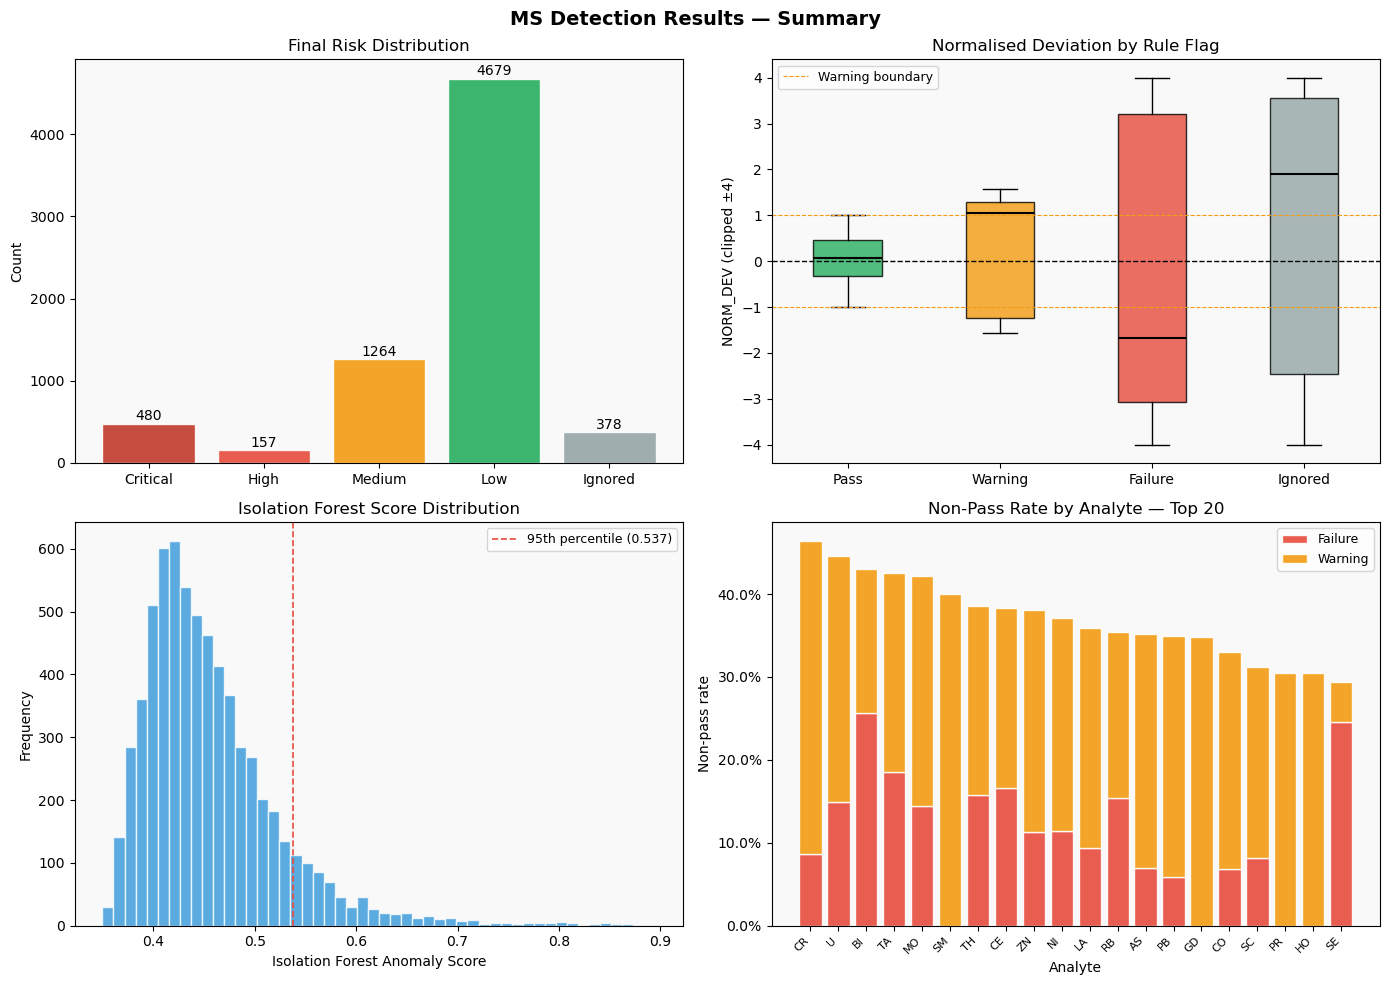

In [13]:
RISK_COLOUR_MAP = {
    "Critical": "#c0392b",
    "High":     "#e74c3c",
    "Medium":   "#f39c12",
    "Low":      "#27ae60",
    "Ignored":  "#95a5a6",
}
RULE_COLOUR_MAP = {
    "Failure": "#e74c3c",
    "Warning": "#f39c12",
    "Pass":    "#27ae60",
    "Ignored": "#95a5a6",
}

# --- Plot 1-4: Summary overview ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MS Detection Results — Summary", fontsize=14, fontweight="bold")

# 1a. Final risk distribution
ax = axes[0, 0]
risk_order  = ["Critical", "High", "Medium", "Low", "Ignored"]
r_counts    = [df["FINAL_RISK"].eq(r).sum() for r in risk_order]
r_colours   = [RISK_COLOUR_MAP[r] for r in risk_order]
bars = ax.bar(risk_order, r_counts, color=r_colours, alpha=0.9, edgecolor="white")
for bar, count in zip(bars, r_counts):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontsize=10
        )
ax.set_ylabel("Count")
ax.set_title("Final Risk Distribution")
ax.set_facecolor("#f9f9f9")

# 1b. NORM_DEV by rule flag
ax = axes[0, 1]
flag_order     = ["Pass", "Warning", "Failure", "Ignored"]
data_by_flag   = [
    df[df["RULE_FLAG"] == f]["NORM_DEV"].dropna().clip(-4, 4)
    for f in flag_order
]
bp = ax.boxplot(
    data_by_flag, labels=flag_order, patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5)
)
for patch, colour in zip(bp["boxes"], [RULE_COLOUR_MAP[f] for f in flag_order]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)
ax.axhline(0,  color="black",   linestyle="--", linewidth=1)
ax.axhline(1,  color="#f39c12", linestyle="--", linewidth=0.8, label="Warning boundary")
ax.axhline(-1, color="#f39c12", linestyle="--", linewidth=0.8)
ax.set_ylabel("NORM_DEV (clipped ±4)")
ax.set_title("Normalised Deviation by Rule Flag")
ax.legend(fontsize=9)
ax.set_facecolor("#f9f9f9")

# 1c. Isolation Forest score distribution
ax = axes[1, 0]
ax.hist(
    df[~df["IS_IGNORED"]]["IF_SCORE"].dropna(),
    bins=50, color="#3498db", alpha=0.8, edgecolor="white"
)
threshold = (
    df[~df["IF_ANOMALY"] & ~df["IS_IGNORED"]]["IF_SCORE"].quantile(0.95)
)
ax.axvline(
    threshold, color="#e74c3c", linestyle="--", linewidth=1.2,
    label=f"95th percentile ({threshold:.3f})"
)
ax.set_xlabel("Isolation Forest Anomaly Score")
ax.set_ylabel("Frequency")
ax.set_title("Isolation Forest Score Distribution")
ax.legend(fontsize=9)
ax.set_facecolor("#f9f9f9")

# 1d. Non-pass rate by analyte — top 20
ax = axes[1, 1]
analyte_flags = (
    df[df["RULE_FLAG"] != "Ignored"]
    .groupby("ANALYTE_CODE")["RULE_FLAG"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
for col in ["Pass", "Warning", "Failure"]:
    if col not in analyte_flags.columns:
        analyte_flags[col] = 0
analyte_flags["non_pass_rate"] = 1 - analyte_flags.get("Pass", 0)
analyte_flags = analyte_flags.sort_values("non_pass_rate", ascending=False).head(20)
bottom = np.zeros(len(analyte_flags))
for col, colour in [("Failure", "#e74c3c"), ("Warning", "#f39c12")]:
    if col in analyte_flags.columns:
        vals = analyte_flags[col].values
        ax.bar(
            analyte_flags.index, vals, bottom=bottom,
            color=colour, alpha=0.9, label=col, edgecolor="white"
        )
        bottom += vals
ax.set_xlabel("Analyte")
ax.set_ylabel("Non-pass rate")
ax.set_title("Non-Pass Rate by Analyte — Top 20")
ax.legend(fontsize=9)
ax.set_xticklabels(analyte_flags.index, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_facecolor("#f9f9f9")

fig.tight_layout()
plt.show()



## 10. Final Output

In [14]:
OUTPUT_COLS = [
    "STD_LOT_CODE", "SCHEME_CODE", "ANALYTE_CODE", "JOB_CODE",
    "ANALYSED_DATE",
    "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
    "INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE",
    "INTERNAL_MIN_WARNING_VALUE", "INTERNAL_MAX_WARNING_VALUE",
    "TRANSFORMED_VALUE",
    "NORM_DEV", "ROBUST_Z_SCORE",
    "ROLLING_MEAN_NORM_DEV", "ROLLING_BREACH_COUNT",
    "STANDARD_STATUS",
    "RULE_FLAG", "RULE_FLAG_COLOUR",
    "IF_SCORE", "IF_ANOMALY", "IF_STATUS", "IF_MODEL",
    "FINAL_RISK", "DETECTION_METHOD", "REASON",
    "CCLAS_MISMATCH",
]

results = df[[c for c in OUTPUT_COLS if c in df.columns]].copy()

# Exclude ignored from top of output - kept in full export only
results_flagged = (
    results[results["FINAL_RISK"] != "Ignored"]
    .sort_values("IF_SCORE", ascending=False)
)

print("Final output preview — non-ignored records sorted by IF score (top 15):")
display(results_flagged.head(15))

print()
print("Summary:")
summary = pd.DataFrame([
    ["Total MS records",              len(results)],
    ["Rule PASS",                     int(results["RULE_FLAG"].eq("Pass").sum())],
    ["Rule WARNING",                  int(results["RULE_FLAG"].eq("Warning").sum())],
    ["Rule FAILURE",                  int(results["RULE_FLAG"].eq("Failure").sum())],
    ["Ignored",                       int(results["RULE_FLAG"].eq("Ignored").sum())],
    ["IF anomalies",                  int(results["IF_ANOMALY"].sum())],
    ["Risk Critical",                 int(results["FINAL_RISK"].eq("Critical").sum())],
    ["Risk High",                     int(results["FINAL_RISK"].eq("High").sum())],
    ["Risk Medium",                   int(results["FINAL_RISK"].eq("Medium").sum())],
    ["Risk Low",                      int(results["FINAL_RISK"].eq("Low").sum())],
    ["Drift candidates",              int((results["ROLLING_MEAN_NORM_DEV"].abs() > CONFIG["drift_threshold"]).sum())],
    ["CCLAS mismatches",              int(df["CCLAS_MISMATCH"].sum())],
    ["Per-analyte IF models used",    int((results.get("IF_MODEL", "") == "per-analyte").sum())],
], columns=["Metric", "Value"])
display(summary)


Final output preview — non-ignored records sorted by IF score (top 15):


,STD_LOT_CODE,SCHEME_CODE,ANALYTE_CODE,JOB_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MAX_WARNING_VALUE,TRANSFORMED_VALUE,NORM_DEV,ROBUST_Z_SCORE,ROLLING_MEAN_NORM_DEV,ROLLING_BREACH_COUNT,STANDARD_STATUS,RULE_FLAG,RULE_FLAG_COLOUR,IF_SCORE,IF_ANOMALY,IF_STATUS,IF_MODEL,FINAL_RISK,DETECTION_METHOD,REASON,CCLAS_MISMATCH
62,OREAS_502C,GE_ICP40Q12,AG,TSV_LB0004352597,2020-11-04 07:56:06.000,2743.776650,0.779,-0.548883,2.106883,-0.063255,1.621255,2065.691649,3256.731395,10636.883914,325.855097,1.0,UpperFailure,Failure,red,0.895206,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (2065.6916) above upper fail...,False
2664,OREAS_502C,GE_ICP40Q12,SE,TSV_LB0004352597,2020-11-04 07:56:06.000,1935.360406,3.400,0.559980,6.240020,1.598680,5.201320,680.262958,1072.524819,247.469433,108.977905,9.0,UpperFailure,Failure,red,0.880070,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (680.263) above upper failur...,False
2292,OREAS_502C,GE_ICP40Q12,S,TSV_LB0004352597,2020-11-04 07:56:06.000,1.822988,0.826,0.718372,0.933628,0.757772,0.894228,9.263293,14.612676,20.720287,0.859464,4.0,UpperFailure,Failure,red,0.871492,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (9.2633) above upper failure...,False
1966,OREAS_502C,GE_ICP40Q12,P,TSV_LB0004352597,2020-11-04 07:56:06.000,1.327829,0.099,0.064103,0.133898,0.076864,0.121136,35.212535,55.511711,92.378343,5.868173,3.0,UpperFailure,Failure,red,0.868449,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (35.2125) above upper failur...,False
1242,OREAS_502C,GE_ICP40Q12,FE,TSV_LB0004352597,2020-11-04 07:56:06.000,6.811356,4.920,4.402908,5.437092,4.591836,5.248164,3.657679,5.763449,7.595883,0.480309,2.0,UpperFailure,Failure,red,0.860004,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (3.6577) above upper failure...,False
3242,OREAS_502C,GE_ICP40Q12,W,TSV_LB0004352597,2020-11-04 07:56:06.000,43.583756,4.530,-20.923164,29.983164,-11.614920,20.674920,1.534338,2.418950,11.646662,0.290679,1.0,UpperFailure,Failure,red,0.858256,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (1.5343) above upper failure...,False
3402,OREAS_502C,GE_ICP40Q12,ZN,TSV_LB0003795682,2020-09-28 07:28:23.000,-88.663636,109.000,95.603900,122.396100,100.498000,117.502000,-14.755312,-23.249075,-20.962681,-0.951299,7.0,LowerFailure,Failure,red,0.853912,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (-14.7553) below lower failu...,False
6554,OREAS_502C,GE_IMS40Q12,W,TSV_LB0004344113,2020-11-11 01:39:09.000,0.750495,4.530,3.826944,5.233056,4.084248,4.975752,-5.375823,-8.478941,-8.893938,-0.872028,4.0,LowerFailure,Failure,red,0.849293,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (-5.3758) below lower failur...,False
4612,OREAS_502C,GE_IMS40Q12,CU,TSV_LB0012520490,2021-08-06 12:10:20.242,4597.319520,7827.000,7044.300000,8609.700000,7330.768200,8323.231800,-4.126333,-6.508411,-8.070474,-0.372549,2.0,LowerFailure,Failure,red,0.847382,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (-4.1263) below lower failur...,False
5223,OREAS_502C,GE_IMS40Q12,NI,TSV_LB0004456358,2020-11-13 17:11:38.000,0.000000,38.100,33.040320,43.159680,34.891980,41.308020,-7.530120,-11.876485,-12.792486,-1.279724,3.0,LowerFailure,Failure,red,0.844125,True,WARNING,per-analyte,Critical,Rule-based,Transformed value (-7.5301) below lower failur...,False



Summary:


,Metric,Value
0,Total MS records,6958
1,Rule PASS,4748
2,Rule WARNING,1352
3,Rule FAILURE,480
4,Ignored,378
5,IF anomalies,643
6,Risk Critical,480
7,Risk High,157
8,Risk Medium,1264
9,Risk Low,4679


## 11. Export

In [15]:
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Full export - all records including ignored
full_path = output_dir / "ms_detection_results.csv"
results.sort_values("IF_SCORE", ascending=False).to_csv(full_path, index=False)
print(f"Full export:    {len(results)} rows → '{full_path}'")

# Flagged only - Critical, High, Medium for QC Chemist review
flagged_path = output_dir / "ms_detection_flagged.csv"
results_flagged.to_csv(flagged_path, index=False)
print(f"Flagged export: {len(results_flagged[results_flagged['FINAL_RISK'].isin(['Critical','High','Medium'])])} rows → '{flagged_path}'")

Full export:    6958 rows → 'data/processed/ms_detection_results.csv'
Flagged export: 1901 rows → 'data/processed/ms_detection_flagged.csv'
